In [1]:
!pip install -q kaggle

import os

os.environ['KAGGLE_API_TOKEN'] ="KGAT_419aba00e571f43896c84f4f91475656"


In [2]:
!mkdir -p ~/.kaggle
!echo KGAT_419aba00e571f43896c84f4f91475656 > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token

In [3]:
!kaggle datasets download -d moltean/fruits


Dataset URL: https://www.kaggle.com/datasets/moltean/fruits
License(s): CC-BY-SA-4.0
100% 6.25G/6.25G [05:05<00:00, 22.0MB/s]



In [4]:
!unzip -q fruits.zip -d fruits_dataset

In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,Dense,Flatten,Dropout,MaxPooling2D
import matplotlib.pyplot as plt


In [6]:
train_ds=tf.keras.utils.image_dataset_from_directory('fruits_dataset/fruits-360_100x100/fruits-360/Training',validation_split=0.2,subset='training',seed=42,image_size=(128,128),batch_size=32)

val_ds=tf.keras.utils.image_dataset_from_directory('fruits_dataset/fruits-360_100x100/fruits-360/Test',validation_split=0.2,subset='validation',seed=42,image_size=(128,128),batch_size=32)

Found 137221 files belonging to 260 classes.
Using 109777 files for training.
Found 45724 files belonging to 260 classes.
Using 9144 files for validation.


In [7]:
normalization_layers=tf.keras.layers.Rescaling(1./255)



train_data=train_ds.map(lambda x,y:(normalization_layers(x),y))
test_data=val_ds.map(lambda x,y:(normalization_layers(x),y))



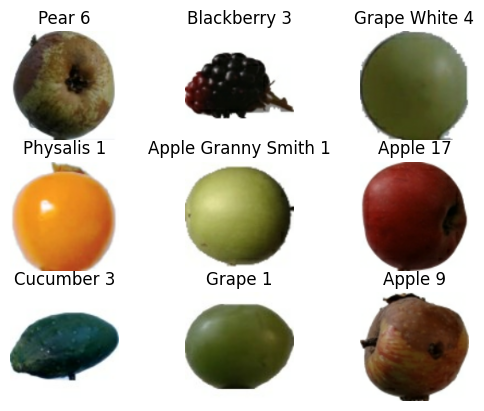

In [8]:
class_names=train_ds.class_names

for images,labels in train_data.take(1):
  for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title(class_names[labels[i]])
    plt.axis('off')

plt.show()

In [12]:
model=Sequential()


model.add(Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)))
model.add(MaxPooling2D())

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D())

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D())

model.add(Conv2D(256,(3,3),activation='relu'))
model.add(MaxPooling2D())

model.add(Flatten())
model.add(Dense(512,activation='relu'))
model.add(Dropout(0.5))


model.add(Dense(len(class_names),activation='softmax'))





/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [14]:
model.fit(train_data,validation_data=(test_data),verbose=1,epochs=10)

Epoch 1/10
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 85s 23ms/step - accuracy: 0.7320 - loss: 1.0108 - val_accuracy: 0.9407 - val_loss: 0.4666
Epoch 2/10
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 77s 22ms/step - accuracy: 0.9386 - loss: 0.1807 - val_accuracy: 0.9494 - val_loss: 0.4994
Epoch 3/10
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 76s 22ms/step - accuracy: 0.9593 - loss: 0.1175 - val_accuracy: 0.9513 - val_loss: 0.5437
Epoch 4/10
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 76s 22ms/step - accuracy: 0.9683 - loss: 0.0931 - val_accuracy: 0.9516 - val_loss: 0.6527
Epoch 5/10
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 78s 23ms/step - accuracy: 0.9754 - loss: 0.0741 - val_accuracy: 0.9517 - val_loss: 0.7205
Epoch 6/10
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 76s 22ms/step - accuracy: 0.9790 - loss: 0.0663 - val_accuracy: 0.9608 - val_loss: 0.6553
Epoch 7/10
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 75s 22ms/step - accuracy: 0.9822 - loss: 0.0548 - val_accuracy: 0.9628 - val_loss: 0.6595
Epoch 8/10
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 75s 22ms/step - accuracy: 0.9838 -

In [17]:
import numpy as np
from tensorflow.keras.preprocessing import image


img_path = '/content/fruits_dataset/fruits-360_100x100/fruits-360/Test/Avocado 2/100_100.jpg'
img = image.load_img(img_path, target_size=(128, 128))


img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)


predictions = model.predict(img_array)


predicted_class_idx = np.argmax(predictions[0])


predicted_class_name = class_names[predicted_class_idx]

print(f"Predicted Class: {predicted_class_name}")
# print(f"Confidence: {predictions[0][predicted_class_idx] * 100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Predicted Class: Avocado 2


In [18]:
model.save("fruits_360.h5")